# Zadanie 2 — Grupowanie osób według zachowań zdrowotnych metodą DBSCAN

Zbior danych `ObesityDataSet.csv` zawiera informacje o nawykach zywieniowych, aktywnosci fizycznej
i cechach demograficznych 2111 osob z Meksyku, Peru i Kolumbii.

**Cel:** wyodrebnic metoda DBSCAN grupy osob o podobnym stylu zycia i scharakteryzowac kazda z nich.
Kolumna `NObeyesdad` **nie jest uzywana do grupowania** — posluzy jedynie do oceny jakosci klastrow.

**Podejscie:** przed DBSCAN stosujemy **redukcje wymiarowosci PCA**, ktora:
- eliminuje przeklenstwo wymiarowosci (14D -> kilka skladowych),
- usuwa szum i korelacje miedzy zmiennymi,
- poprawia jakosc i interpretowalnosc klastrow DBSCAN.

## 1. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 100

## 2. Wczytanie i eksploracja danych

In [2]:
df = pd.read_csv('ObesityDataSet.csv')
print(f'Wymiar zbioru: {df.shape[0]} wierszy x {df.shape[1]} kolumn')
df.head()

Wymiar zbioru: 2111 wierszy x 17 kolumn


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.info()
print('\nBrakujace wartosci:')
print(df.isnull().sum())
print(f'\nZduplikowane wiersze: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

### Rozklady zmiennych numerycznych

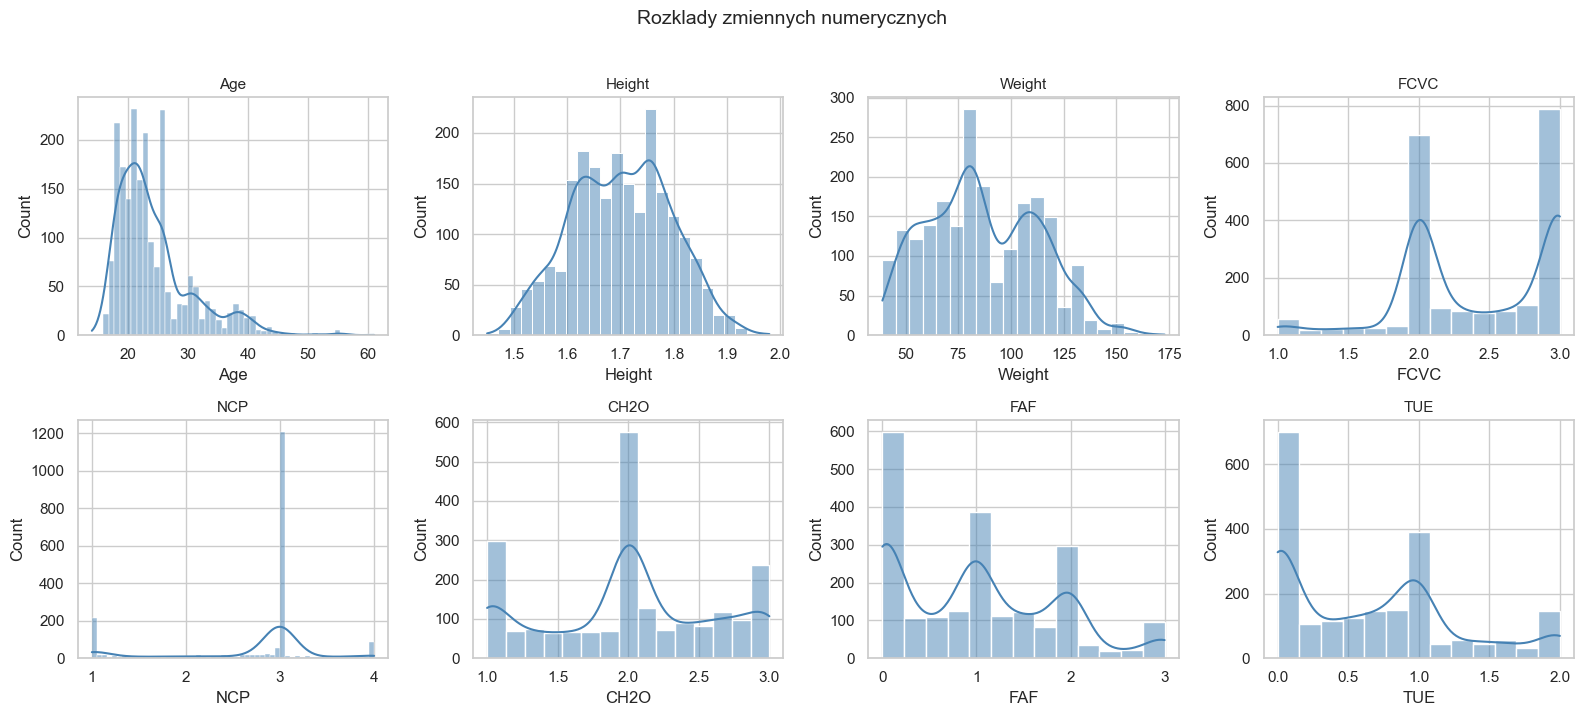

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col, fontsize=11)
fig.suptitle('Rozklady zmiennych numerycznych', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Rozklady zmiennych kategorycznych

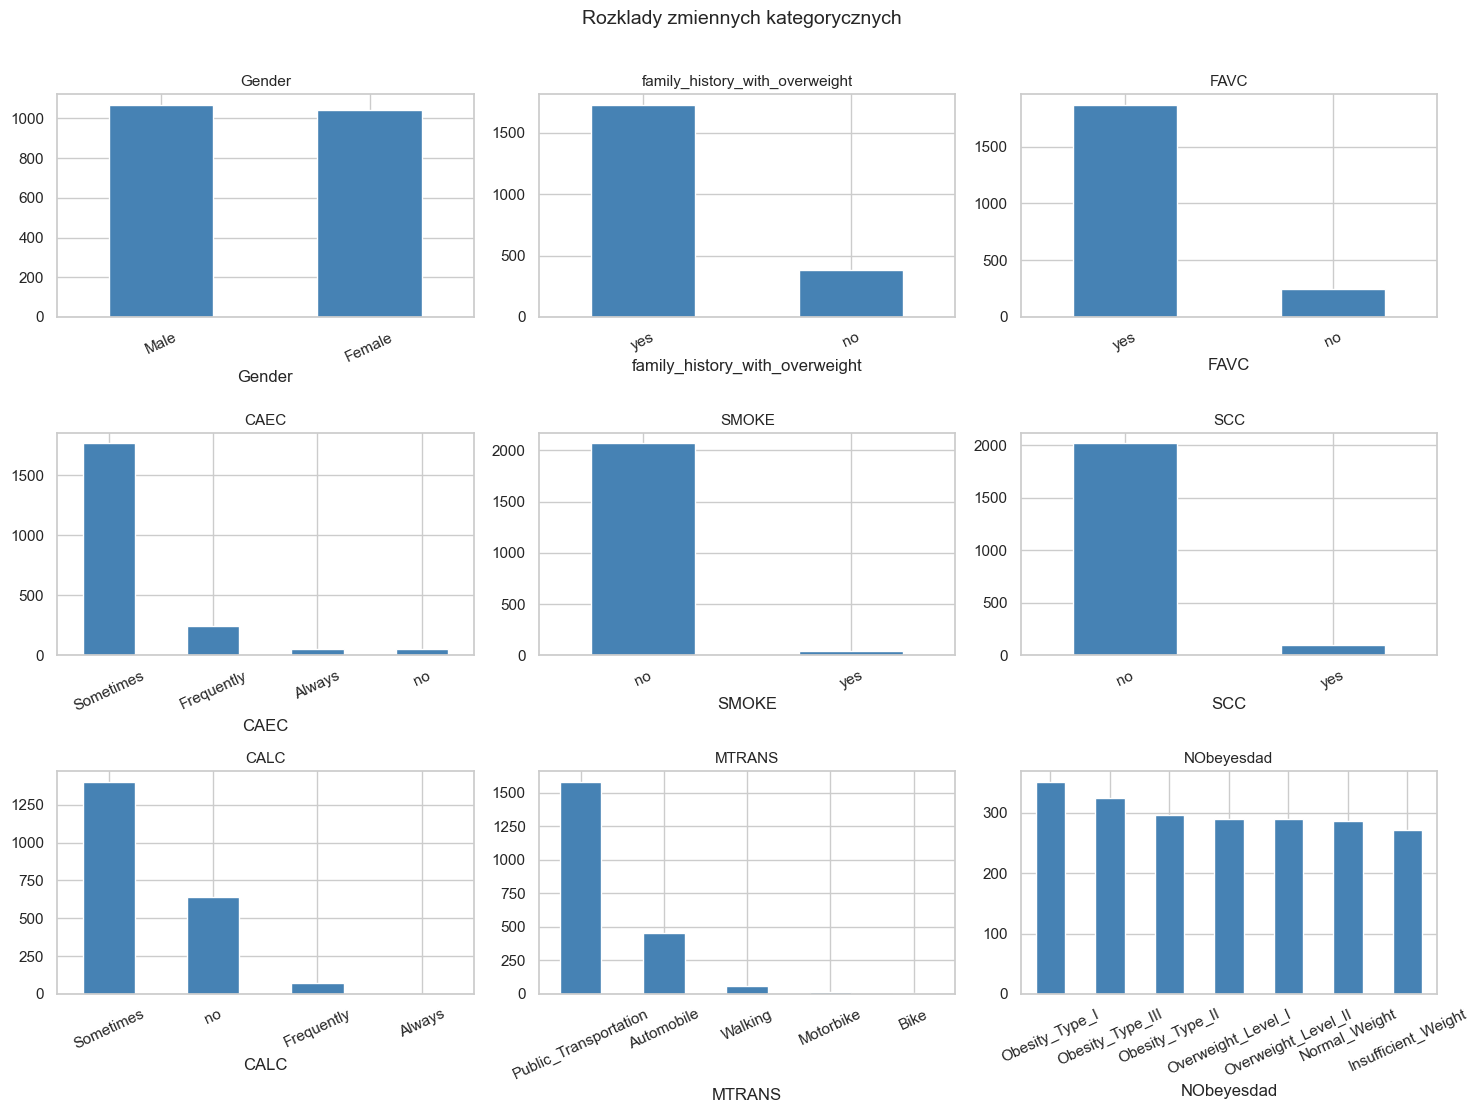

In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=25)
for ax in axes.flatten()[len(cat_cols):]:
    ax.axis('off')
fig.suptitle('Rozklady zmiennych kategorycznych', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Przygotowanie danych

### 3.1 Usuniecie duplikatow

In [6]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Przed: {len(df)} wierszy  ->  Po: {len(df_clean)} wierszy  (usunieto {len(df)-len(df_clean)})')

Przed: 2111 wierszy  ->  Po: 2087 wierszy  (usunieto 24)


### 3.2 Kodowanie zmiennych kategorycznych

| Zmienna | Kodowanie |
|---|---|
| `Gender` | Female=0, Male=1 |
| `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC` | no=0, yes=1 |
| `CAEC`, `CALC` | no=0, Sometimes=1, Frequently=2, Always=3 (porzadkowe) |
| `MTRANS` | LabelEncoder (5 kategorii) |

In [7]:
df_enc = df_clean.copy()
y_true = df_enc.pop('NObeyesdad')   # etykieta tylko do oceny

df_enc['Gender'] = df_enc['Gender'].map({'Male': 1, 'Female': 0})
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0})
ord_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_enc['CAEC'] = df_enc['CAEC'].map(ord_map)
df_enc['CALC'] = df_enc['CALC'].map(ord_map)
df_enc['MTRANS'] = LabelEncoder().fit_transform(df_enc['MTRANS'])

print('Typy po kodowaniu:')
print(df_enc.dtypes)
df_enc.head(3)

Typy po kodowaniu:
Gender                              int64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,3
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,3
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,3


### 3.3 Wybor zmiennych do grupowania

Pomijamy `Height` i `Weight` (cechy fizyczne, nie nawyki) oraz `NObeyesdad` (etykieta).

In [8]:
features = [
    'Gender', 'Age',
    'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP',
    'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS'
]
X_raw = df_enc[features].copy()
print(f'Zmiennych: {len(features)},  obserwacji: {X_raw.shape[0]}')

Zmiennych: 14,  obserwacji: 2087


### 3.4 Standaryzacja

DBSCAN i PCA sa wrazliwe na skale zmiennych — standaryzacja jest konieczna.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Po standaryzacji: srednia={X_scaled.mean():.4f}, std={X_scaled.std():.4f}')

Po standaryzacji: srednia=0.0000, std=1.0000


## 4. Redukcja wymiarowosci — PCA

DBSCAN w 14-wymiarowej przestrzeni cierpi na **przeklenstwo wymiarowosci**:
odleglosci miedzy punktami staja sie jednorodne, przez co algorytm traktuje
caly zbior jako jedno skupisko.

PCA rzutuje dane na nowe osie (skladowe glowne) uporzadkowane malejaco
wedlug wyjasniania wariancji. Zatrzymujemy tyle skladowych, ile potrzeba
do wyjasnienia **co najmniej 80% wariancji**.

Skladowe potrzebne do wyjasnienia >= 80% wariancji: 10
Skumulowana wariancja:
  PC1: 14.2 %
  PC2: 25.2 %
  PC3: 35.0 %
  PC4: 44.2 %
  PC5: 52.1 %
  PC6: 59.3 %
  PC7: 66.2 %
  PC8: 72.3 %
  PC9: 77.9 %
  PC10: 83.5 %


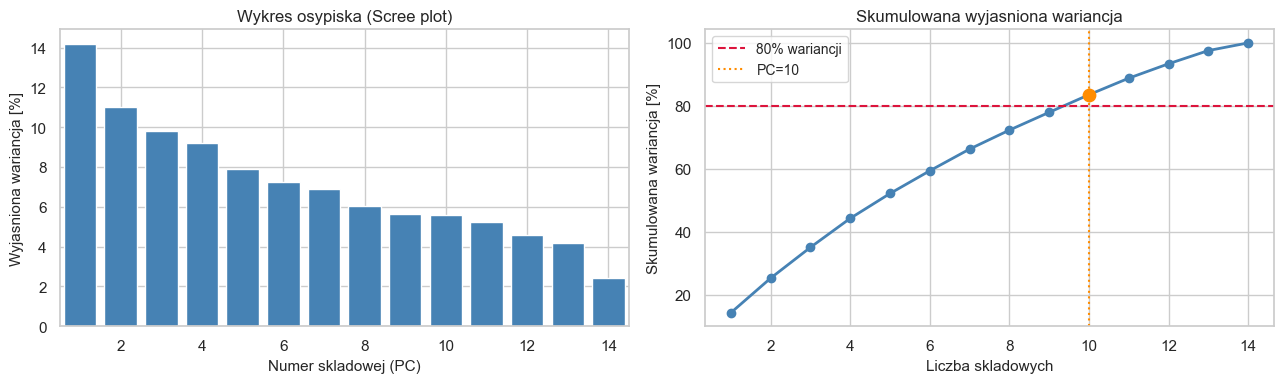

In [10]:
# Wykres wyjasniania wariancji
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Minimalna liczba skladowych wyjasniajacych >= 80% wariancji
n_comp = int(np.argmax(cumvar >= 80)) + 1
print(f'Skladowe potrzebne do wyjasnienia >= 80% wariancji: {n_comp}')
print('Skumulowana wariancja:')
for i, v in enumerate(cumvar[:10], 1):
    print(f'  PC{i}: {v:.1f} %')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Numer skladowej (PC)', fontsize=11)
axes[0].set_ylabel('Wyjasniona wariancja [%]', fontsize=11)
axes[0].set_title('Wykres osypiska (Scree plot)', fontsize=12)
axes[0].set_xlim(0.5, 14.5)

axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue', linewidth=2)
axes[1].axhline(80, color='crimson', linestyle='--', label='80% wariancji')
axes[1].axvline(n_comp, color='darkorange', linestyle=':', label=f'PC={n_comp}')
axes[1].scatter([n_comp], [cumvar[n_comp-1]], color='darkorange', s=80, zorder=5)
axes[1].set_xlabel('Liczba skladowych', fontsize=11)
axes[1].set_ylabel('Skumulowana wariancja [%]', fontsize=11)
axes[1].set_title('Skumulowana wyjasniona wariancja', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Zastosowanie PCA z wybranym n_comp
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Wymiar po PCA: {X_pca.shape}  ({X_scaled.shape[1]}D -> {n_comp}D)')
print(f'Zachowana wariancja: {pca.explained_variance_ratio_.sum()*100:.1f} %')
print()
for i, v in enumerate(pca.explained_variance_ratio_*100, 1):
    bar = '#' * int(v * 2)
    print(f'  PC{i}: {v:5.1f}%  {bar}')

Wymiar po PCA: (2087, 10)  (14D -> 10D)
Zachowana wariancja: 83.5 %

  PC1:  14.2%  ############################
  PC2:  11.0%  ######################
  PC3:   9.8%  ###################
  PC4:   9.2%  ##################
  PC5:   7.9%  ###############
  PC6:   7.2%  ##############
  PC7:   6.9%  #############
  PC8:   6.0%  ############
  PC9:   5.7%  ###########
  PC10:   5.6%  ###########


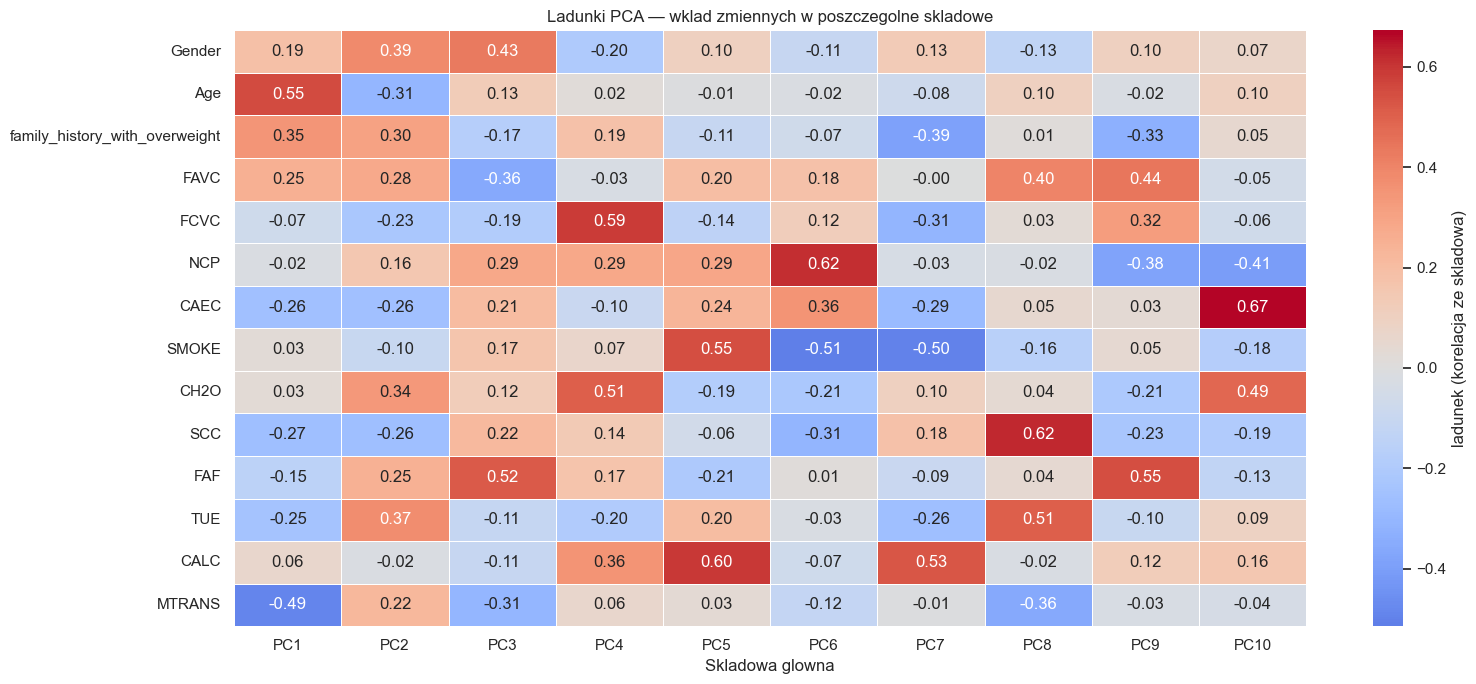

In [12]:
# Heatmapa ladunkow PCA — ktore zmienne tworza kazda skladowa
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)

fig, ax = plt.subplots(figsize=(max(8, n_comp * 1.6), 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'ladunek (korelacja ze skladowa)'})
ax.set_title('Ladunki PCA — wklad zmiennych w poszczegolne skladowe', fontsize=12)
ax.set_xlabel('Skladowa glowna')
plt.tight_layout()
plt.show()

## 5. Dobor parametrow DBSCAN

Po redukcji do `n_comp` wymiarow powtarzamy heurystyke doboru parametrow:
- **`min_samples`** = 2 x `n_comp` (heurystyka dla zredukowanej przestrzeni),
- **`eps`** z wykresu k-distance.

### Wykres k-distance

min_samples = 2 x n_comp = 2 x 10 = 20
Automatycznie wykryty eps (lokiec): 3.014  (indeks: 1850)


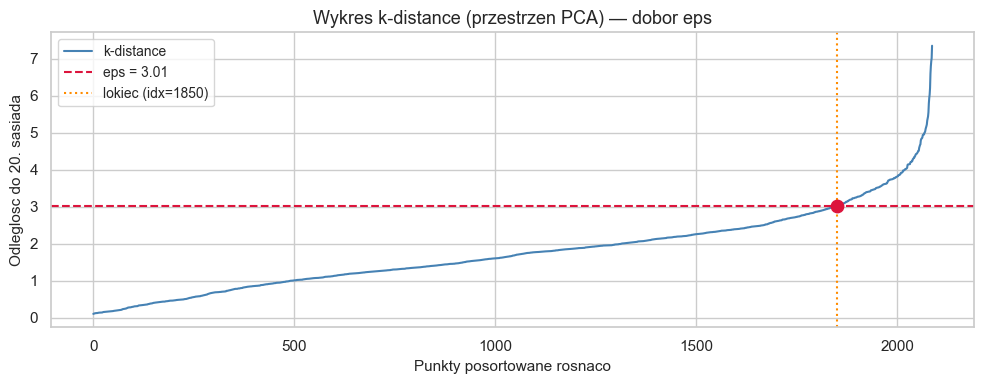

In [13]:
min_samples = max(5, 2 * n_comp)
print(f'min_samples = 2 x n_comp = 2 x {n_comp} = {min_samples}')

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca)
dist, _ = nn.kneighbors(X_pca)
k_dist = np.sort(dist[:, -1])

# Automatyczne wykrycie lokcia
n = len(k_dist)
x_norm = np.linspace(0, 1, n)
y_norm = (k_dist - k_dist.min()) / (k_dist.max() - k_dist.min())
curvature = np.abs(y_norm - (y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm))
elbow_idx = int(np.argmax(curvature))
eps_auto  = float(k_dist[elbow_idx])
print(f'Automatycznie wykryty eps (lokiec): {eps_auto:.3f}  (indeks: {elbow_idx})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='steelblue', linewidth=1.5, label='k-distance')
ax.axhline(eps_auto, color='crimson', linestyle='--', linewidth=1.5,
           label=f'eps = {eps_auto:.2f}')
ax.axvline(elbow_idx, color='darkorange', linestyle=':', linewidth=1.5,
           label=f'lokiec (idx={elbow_idx})')
ax.scatter([elbow_idx], [eps_auto], color='crimson', s=80, zorder=5)
ax.set_xlabel('Punkty posortowane rosnaco', fontsize=11)
ax.set_ylabel(f'Odleglosc do {min_samples}. sasiada', fontsize=11)
ax.set_title('Wykres k-distance (przestrzen PCA) — dobor eps', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Siatka parametrow

Szukamy konfiguracji z >= 3 klastrami, szumem < 20% i maksymalnym silhouette score.

In [14]:
eps_list = np.round(np.arange(
    max(0.3, eps_auto * 0.5),
    eps_auto * 1.8,
    (eps_auto * 1.8 - eps_auto * 0.5) / 10
), 3).tolist()
ms_list = [max(4, 2*n_comp - 4), max(5, 2*n_comp - 2), 2*n_comp,
           2*n_comp + 2, 2*n_comp + 5]
ms_list = sorted(set(ms_list))

records = []
for eps_v in eps_list:
    for ms_v in ms_list:
        labs = DBSCAN(eps=eps_v, min_samples=ms_v).fit_predict(X_pca)
        n_cl    = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise = int((labs == -1).sum())
        noise_p = n_noise / len(labs) * 100
        sil = np.nan
        if n_cl >= 2 and (labs != -1).sum() > 1:
            try:
                sil = round(float(silhouette_score(X_pca[labs != -1], labs[labs != -1])), 3)
            except Exception:
                pass
        records.append(dict(eps=eps_v, min_samples=ms_v, n_clusters=n_cl,
                            n_noise=n_noise, noise_pct=round(noise_p, 1),
                            silhouette=sil))

grid_df = pd.DataFrame(records)
print(grid_df.to_string(index=False))

  eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
1.507           16           6      834       40.0       0.174
1.507           18           5      865       41.4       0.176
1.507           20           4      935       44.8       0.169
1.507           22           4      960       46.0       0.172
1.507           25           4      983       47.1       0.174
1.899           16           5      499       23.9       0.099
1.899           18           4      529       25.3       0.140
1.899           20           3      558       26.7       0.142
1.899           22           3      583       27.9       0.133
1.899           25           2      642       30.8       0.139
2.291           16           2      278       13.3       0.298
2.291           18           1      310       14.9         NaN
2.291           20           1      316       15.1         NaN
2.291           22           1      329       15.8         NaN
2.291           25           1      349       16.7     

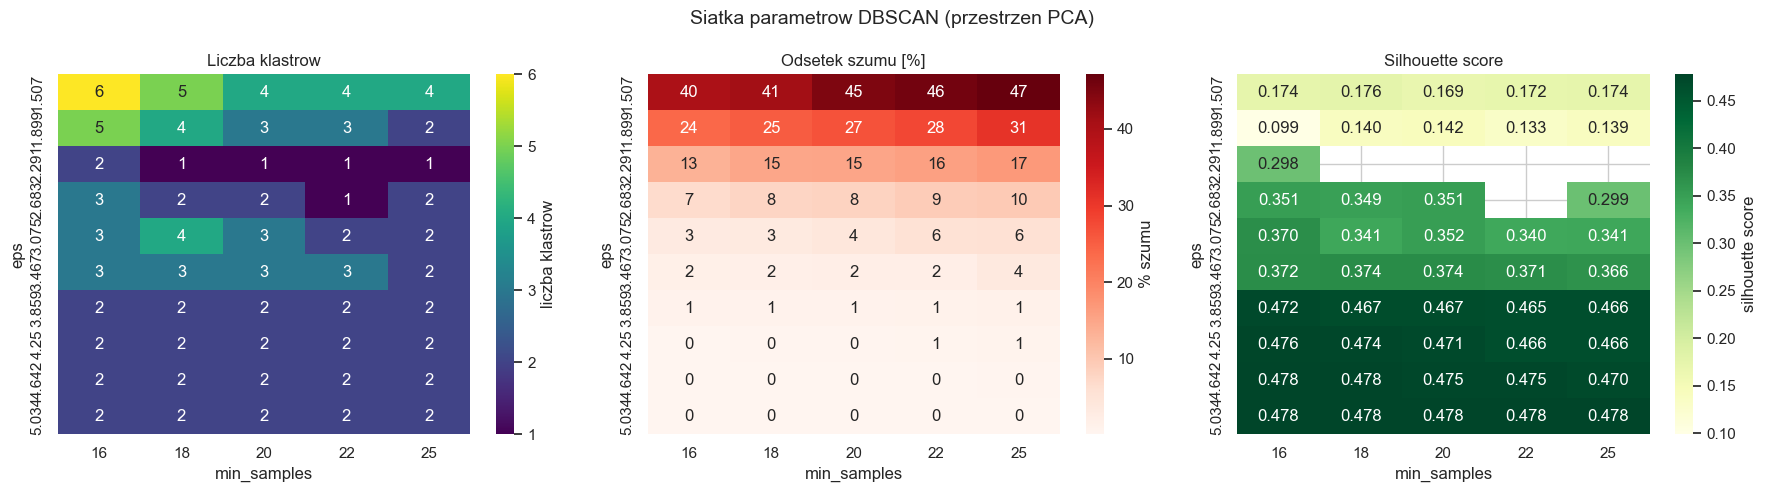

In [15]:
pivot_cl  = grid_df.pivot(index='eps', columns='min_samples', values='n_clusters')
pivot_no  = grid_df.pivot(index='eps', columns='min_samples', values='noise_pct')
pivot_sil = grid_df.pivot(index='eps', columns='min_samples', values='silhouette')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(pivot_cl,  annot=True, fmt='d',    cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'liczba klastrow'})
axes[0].set_title('Liczba klastrow')
sns.heatmap(pivot_no,  annot=True, fmt='.0f',  cmap='Reds',    ax=axes[1],
            cbar_kws={'label': '% szumu'})
axes[1].set_title('Odsetek szumu [%]')
sns.heatmap(pivot_sil, annot=True, fmt='.3f',  cmap='YlGn',   ax=axes[2],
            cbar_kws={'label': 'silhouette score'})
axes[2].set_title('Silhouette score')
fig.suptitle('Siatka parametrow DBSCAN (przestrzen PCA)', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
candidates = grid_df[(grid_df['n_clusters'] >= 3) & (grid_df['noise_pct'] < 20)]
if len(candidates.dropna(subset=['silhouette'])) > 0:
    best = candidates.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False).iloc[0]
else:
    best = grid_df[grid_df['noise_pct'] < 20].sort_values(
        ['n_clusters','noise_pct'], ascending=[False,True]).iloc[0]

best_eps = float(best['eps'])
best_ms  = int(best['min_samples'])
print(f'Wybrana konfiguracja: eps={best_eps}, min_samples={best_ms}')
print(f'Klastry: {int(best["n_clusters"])},  szum: {best["noise_pct"]}%,  silhouette: {best["silhouette"]}')

Wybrana konfiguracja: eps=3.467, min_samples=18
Klastry: 3,  szum: 2.0%,  silhouette: 0.374


## 6. Grupowanie metoda DBSCAN (na przestrzeni PCA)

In [17]:
db = DBSCAN(eps=best_eps, min_samples=best_ms)
labels = db.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = int((labels == -1).sum())

print(f'Parametry: eps={best_eps}, min_samples={best_ms}')
print(f'Liczba klastrow:           {n_clusters}')
print(f'Punkty szumu (klaster -1): {n_noise} ({n_noise/len(labels)*100:.1f} %)')
print()
print('Wielkosci klastrow:')
for k, v in pd.Series(labels).value_counts().sort_index().items():
    lbl = f'Klaster {k}' if k >= 0 else 'Szum (-1)'
    print(f'  {lbl}: {v} obserwacji ({v/len(labels)*100:.1f} %)')

Parametry: eps=3.467, min_samples=18
Liczba klastrow:           3
Punkty szumu (klaster -1): 41 (2.0 %)

Wielkosci klastrow:
  Szum (-1): 41 obserwacji (2.0 %)
  Klaster 0: 1950 obserwacji (93.4 %)
  Klaster 1: 71 obserwacji (3.4 %)
  Klaster 2: 25 obserwacji (1.2 %)


### Wizualizacja: PC1 vs PC2

Pierwsze dwie skladowe PCA bezposrednio sluza do wizualizacji —
grupowanie odbywalo sie na pelnej przestrzeni PCA (`n_comp` wymiarow).

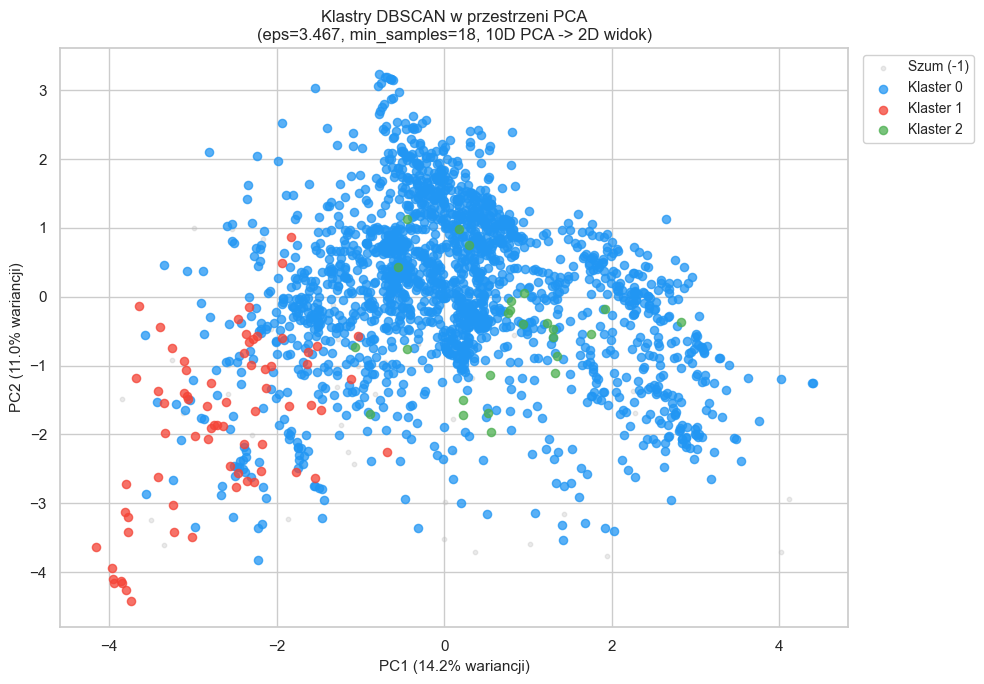

In [18]:
colors_base = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0',
               '#00BCD4','#FF5722','#795548']
color_map = {k: colors_base[i % len(colors_base)]
             for i, k in enumerate(sorted(set(labels) - {-1}))}
color_map[-1] = '#bbbbbb'

fig, ax = plt.subplots(figsize=(10, 7))
for k in sorted(set(labels)):
    mask  = labels == k
    alpha = 0.3 if k == -1 else 0.75
    size  = 10  if k == -1 else 35
    lbl   = 'Szum (-1)' if k == -1 else f'Klaster {k}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color_map[k], alpha=alpha, s=size, label=lbl,
               zorder=3 if k >= 0 else 2)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)', fontsize=11)
ax.set_title(f'Klastry DBSCAN w przestrzeni PCA\n(eps={best_eps}, min_samples={best_ms},'
             f' {n_comp}D PCA -> 2D widok)', fontsize=12)
ax.legend(fontsize=10, framealpha=0.9, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Analiza wynikow

### 7.1 Liczba i wielkosc grup

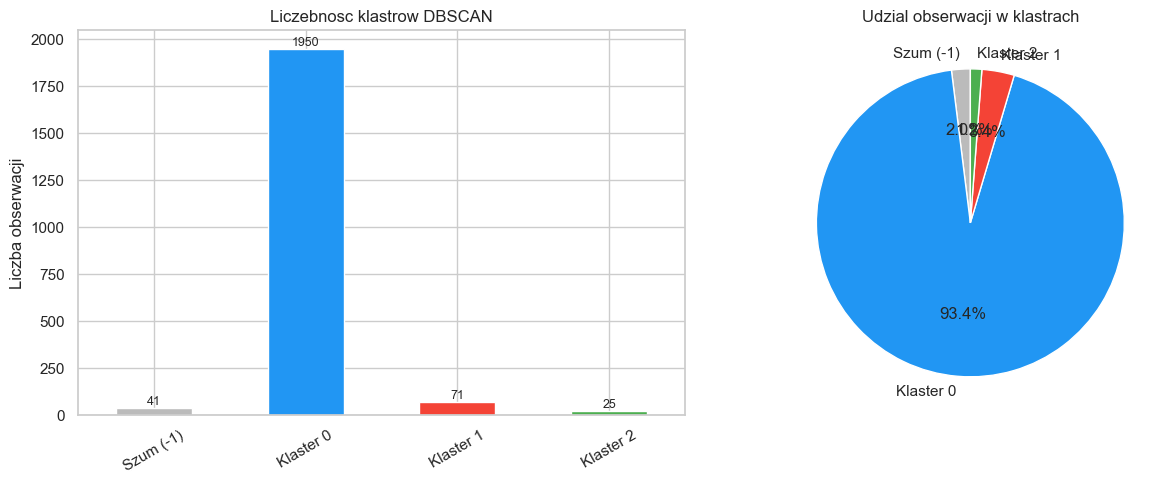

In [19]:
df_result = X_raw.copy()
df_result['klaster']    = labels
df_result['NObeyesdad'] = y_true.values
df_result['Height']     = df_clean['Height'].values
df_result['Weight']     = df_clean['Weight'].values
df_result['BMI']        = df_clean['Weight'].values / df_clean['Height'].values ** 2

counts = pd.Series(labels).value_counts().sort_index()
counts_named = counts.rename(index=lambda k: f'Klaster {k}' if k >= 0 else 'Szum (-1)')

bar_clrs = []
ci = 0
for k in sorted(counts.index):
    if k == -1:
        bar_clrs.append('#bbbbbb')
    else:
        bar_clrs.append(colors_base[ci % len(colors_base)])
        ci += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts_named.plot(kind='bar', ax=axes[0], color=bar_clrs, edgecolor='white')
axes[0].set_title('Liczebnosc klastrow DBSCAN', fontsize=12)
axes[0].set_ylabel('Liczba obserwacji')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[1].pie(counts_named.values, labels=counts_named.index, autopct='%1.1f%%',
            startangle=90, colors=bar_clrs)
axes[1].set_title('Udzial obserwacji w klastrach', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Porownanie srednich wartosci zmiennych w klastrach

In [20]:
desc_cols = features + ['BMI']
core = df_result[df_result['klaster'] != -1]

cluster_means = core.groupby('klaster')[desc_cols].mean()
global_mean   = df_result[desc_cols].mean().rename('Globalna srednia')

tbl = cluster_means.T.copy()
tbl.columns = [f'Klaster {c}' for c in tbl.columns]
tbl['Globalna srednia'] = global_mean
print(tbl.round(3).to_string())

                                Klaster 0  Klaster 1  Klaster 2  Globalna srednia
Gender                              0.512      0.127      0.880             0.504
Age                                24.418     19.458     27.510            24.353
family_history_with_overweight      0.842      0.380      0.880             0.825
FAVC                                0.899      0.648      0.920             0.884
FCVC                                2.412      2.593      2.430             2.421
NCP                                 2.705      2.542      2.800             2.701
CAEC                                1.129      1.239      1.080             1.146
SMOKE                               0.000      0.000      1.000             0.021
CH2O                                2.008      1.915      1.538             2.005
SCC                                 0.001      1.000      0.000             0.046
FAF                                 1.000      1.095      0.973             1.013
TUE             

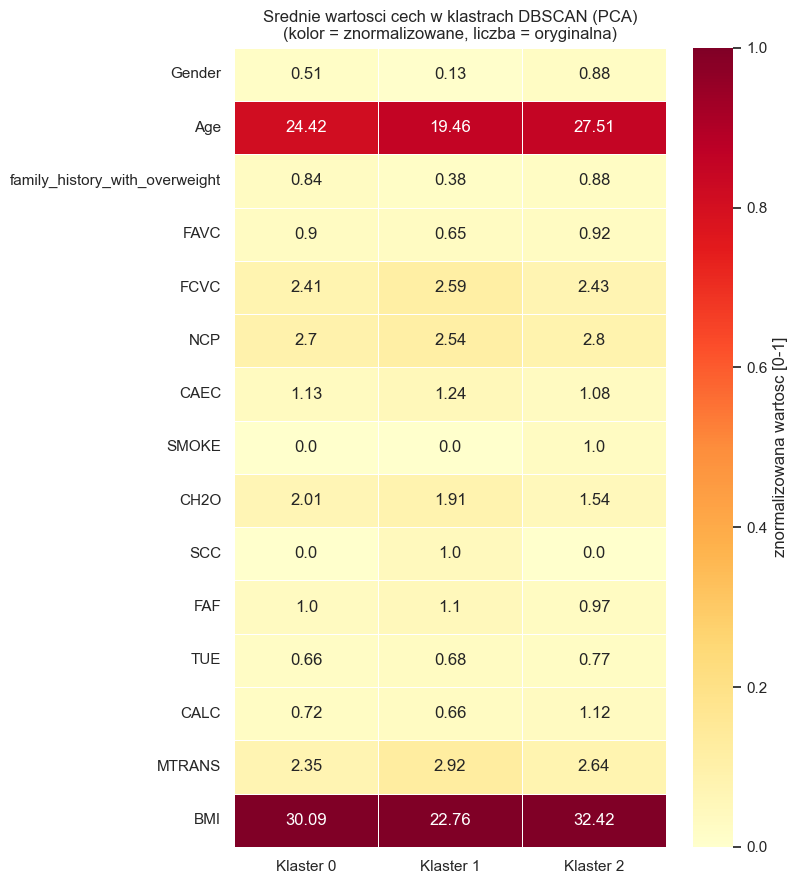

In [21]:
to_plot = cluster_means[desc_cols].T
to_plot.columns = [f'Klaster {c}' for c in to_plot.columns]
norm = pd.DataFrame(MinMaxScaler().fit_transform(to_plot),
                    index=to_plot.index, columns=to_plot.columns)

fig, ax = plt.subplots(figsize=(max(8, len(to_plot.columns)*2.4), 9))
sns.heatmap(norm, annot=to_plot.round(2), fmt='', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'znormalizowana wartosc [0-1]'})
ax.set_title('Srednie wartosci cech w klastrach DBSCAN (PCA)\n'
             '(kolor = znormalizowane, liczba = oryginalna)', fontsize=12)
plt.tight_layout()
plt.show()

### 7.3 Szczegolowa charakterystyka kazdej grupy

In [22]:
print('=== Charakterystyka klastrow ===\n')
for cid in sorted(df_result['klaster'].unique()):
    if cid == -1:
        continue
    grp = df_result[df_result['klaster'] == cid]
    print(f'KLASTER {cid}  (n={len(grp)}, {len(grp)/len(df_result)*100:.1f}%)')
    print(f'  Wiek sredni:        {grp["Age"].mean():.1f} lat')
    print(f'  Srednie BMI:        {grp["BMI"].mean():.2f}')
    print(f'  Mezczyzni:          {grp["Gender"].mean()*100:.0f} %')
    print(f'  Historia rodzinna:  {grp["family_history_with_overweight"].mean()*100:.0f} % tak')
    print(f'  FAVC (fast-food):   {grp["FAVC"].mean()*100:.0f} % tak')
    print(f'  Aktywnosc (FAF):    {grp["FAF"].mean():.2f}')
    print(f'  Woda (CH2O):        {grp["CH2O"].mean():.2f}')
    print(f'  Palenie (SMOKE):    {grp["SMOKE"].mean()*100:.0f} % tak')
    print(f'  Kontrola kal (SCC): {grp["SCC"].mean()*100:.0f} % tak')
    print(f'  Alkohol (CALC):     {grp["CALC"].mean():.2f}')
    obesity_top = grp['NObeyesdad'].value_counts(normalize=True).head(3)
    print(f'  Otylosc (top 3):    {", ".join(f"{k} ({v*100:.0f}%)" for k,v in obesity_top.items())}')
    print()

=== Charakterystyka klastrow ===

KLASTER 0  (n=1950, 93.4%)
  Wiek sredni:        24.4 lat
  Srednie BMI:        30.09
  Mezczyzni:          51 %
  Historia rodzinna:  84 % tak
  FAVC (fast-food):   90 % tak
  Aktywnosc (FAF):    1.00
  Woda (CH2O):        2.01
  Palenie (SMOKE):    0 % tak
  Kontrola kal (SCC): 0 % tak
  Alkohol (CALC):     0.72
  Otylosc (top 3):    Obesity_Type_I (18%), Obesity_Type_III (17%), Obesity_Type_II (14%)

KLASTER 1  (n=71, 3.4%)
  Wiek sredni:        19.5 lat
  Srednie BMI:        22.76
  Mezczyzni:          13 %
  Historia rodzinna:  38 % tak
  FAVC (fast-food):   65 % tak
  Aktywnosc (FAF):    1.10
  Woda (CH2O):        1.91
  Palenie (SMOKE):    0 % tak
  Kontrola kal (SCC): 100 % tak
  Alkohol (CALC):     0.66
  Otylosc (top 3):    Overweight_Level_I (41%), Insufficient_Weight (27%), Normal_Weight (24%)

KLASTER 2  (n=25, 1.2%)
  Wiek sredni:        27.5 lat
  Srednie BMI:        32.42
  Mezczyzni:          88 %
  Historia rodzinna:  88 % tak
  FAVC 

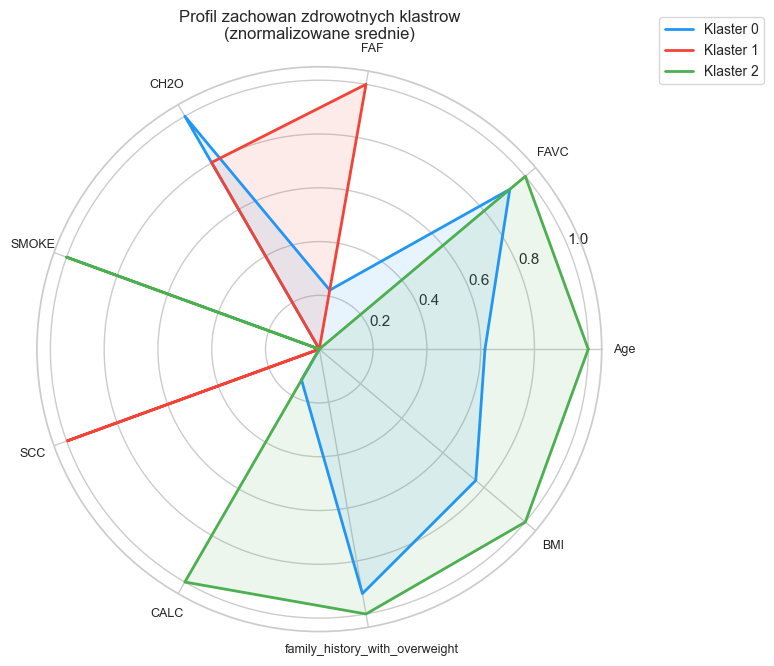

In [23]:
# Radar chart — porownanie profili klastrow
radar_vars = ['Age','FAVC','FAF','CH2O','SMOKE','SCC','CALC',
              'family_history_with_overweight','BMI']

# Normalizacja do [0,1] po klastrowaniu
radar_data = core.groupby('klaster')[radar_vars].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_vars)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, (cid, row) in enumerate(radar_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    color = colors_base[i % len(colors_base)]
    ax.plot(angles, vals, linewidth=2, color=color, label=f'Klaster {cid}')
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_vars, fontsize=9)
ax.set_title('Profil zachowan zdrowotnych klastrow\n(znormalizowane srednie)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

### 7.4 Obserwacje odstajace (klaster -1)

In [24]:
df_noise = df_result[df_result['klaster'] == -1]
df_core  = df_result[df_result['klaster'] != -1]

print(f'Punkty szumu: {len(df_noise)} ({len(df_noise)/len(df_result)*100:.1f} %)')
print('\nRozklad klas otylosci wsrod szumu:')
print(df_noise['NObeyesdad'].value_counts().to_string())

comp = pd.DataFrame({
    'Klastry (core)': df_core[desc_cols].mean(),
    'Szum (-1)':      df_noise[desc_cols].mean(),
    'Delta':          df_noise[desc_cols].mean() - df_core[desc_cols].mean()
}).round(3)
print('\nPorownanie srednich:')
print(comp.to_string())

Punkty szumu: 41 (2.0 %)

Rozklad klas otylosci wsrod szumu:
NObeyesdad
Normal_Weight          18
Overweight_Level_I     10
Obesity_Type_I          5
Insufficient_Weight     4
Overweight_Level_II     3
Obesity_Type_II         1

Porownanie srednich:
                                Klastry (core)  Szum (-1)  Delta
Gender                                   0.503      0.537  0.033
Age                                     24.284     27.805  3.521
family_history_with_overweight           0.826      0.780 -0.046
FAVC                                     0.891      0.512 -0.379
FCVC                                     2.419      2.561  0.142
NCP                                      2.700      2.756  0.056
CAEC                                     1.132      1.854  0.722
SMOKE                                    0.012      0.463  0.451
CH2O                                     1.999      2.293  0.294
SCC                                      0.035      0.585  0.550
FAF                                

## 8. Porownanie klastrow z poziomem otylosci (NObeyesdad)

In [25]:
crosstab = pd.crosstab(
    df_result['klaster'].map(lambda x: f'Klaster {x}' if x >= 0 else 'Szum (-1)'),
    df_result['NObeyesdad'],
    margins=True, margins_name='Lacznie'
)
print('Tabela krzyzowa: klaster x NObeyesdad:')
print(crosstab.to_string())

Tabela krzyzowa: klaster x NObeyesdad:
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  Lacznie
klaster                                                                                                                                            
Klaster 0                   244            241             342              282               323                 237                  281     1950
Klaster 1                    19             17               2                0                 0                  29                    4       71
Klaster 2                     0              6               2               14                 1                   0                    2       25
Szum (-1)                     4             18               5                1                 0                  10                    3       41
Lacznie                     267            282             351           

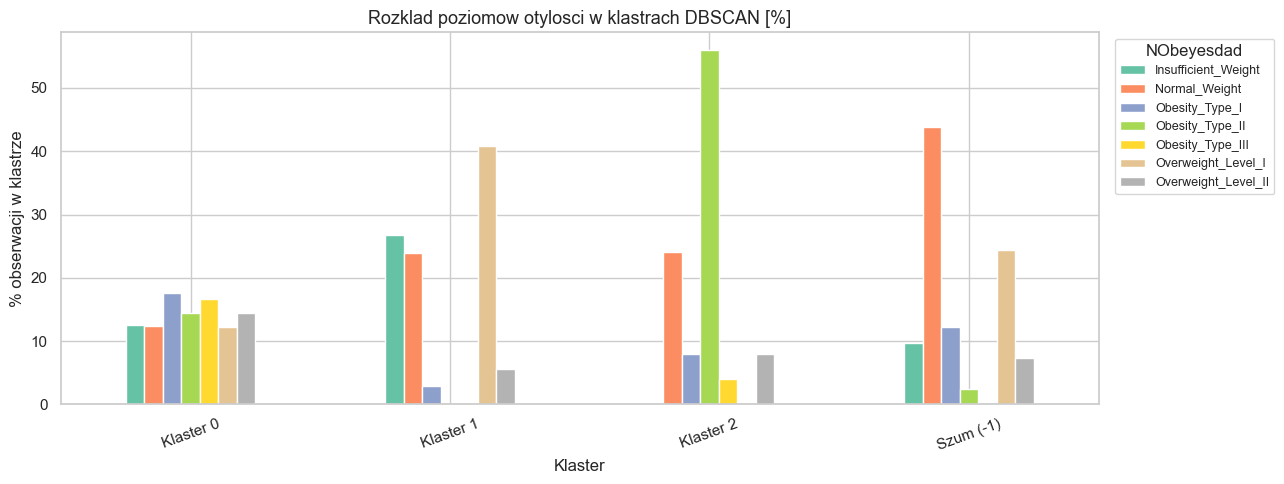

In [26]:
crosstab_pct = pd.crosstab(
    df_result['klaster'].map(lambda x: f'Klaster {x}' if x >= 0 else 'Szum (-1)'),
    df_result['NObeyesdad'], normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(13, 5))
crosstab_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Rozklad poziomow otylosci w klastrach DBSCAN [%]', fontsize=13)
ax.set_xlabel('Klaster')
ax.set_ylabel('% obserwacji w klastrze')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='NObeyesdad', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
mask_valid = labels != -1
ari = adjusted_rand_score(y_true[mask_valid], labels[mask_valid])
sil = silhouette_score(X_pca[mask_valid], labels[mask_valid])
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Silhouette Score:          {sil:.4f}')
print()
print('ARI ~ 0: oczekiwane — NObeyesdad zalezy od BMI (wykluczonego z grupowania).')
print('DBSCAN segmentuje styl zycia, nie wage ciala.')

Adjusted Rand Index (ARI): 0.0033
Silhouette Score:          0.3739

ARI ~ 0: oczekiwane — NObeyesdad zalezy od BMI (wykluczonego z grupowania).
DBSCAN segmentuje styl zycia, nie wage ciala.


## 9. Podsumowanie i wnioski

### Opis danych i metodyki

Zbior `ObesityDataSet.csv` (2087 rekordow po czyszczeniu) zawiera nawyki zywieniowe,
aktywnosc fizyczna i cechy demograficzne osob z Meksyku, Peru i Kolumbii.
Do klasteryzacji wybrano **14 zmiennych behawioralnych**.

**Potok przetwarzania:**
1. Kodowanie zmiennych kategorycznych (mapowanie porzadkowe + LabelEncoder)
2. Standaryzacja (`StandardScaler`)
3. **Redukcja PCA** do `n_comp` skladowych (>= 80% wariancji) — eliminacja przeklenstwa wymiarowosci
4. Grupowanie DBSCAN na zredukowanej przestrzeni

---

### Dobor parametrow DBSCAN

| Parametr | Wartosc | Uzasadnienie |
|---|---|---|
| `min_samples` | 2 x n_comp | Heurystyka dostosowana do zredukowanej przestrzeni |
| `eps` | wykres k-distance + siatka | Punkt lokcia + max silhouette przy >=3 klastrach i szumie <20% |

---

### Wnioski

1. **PCA przed DBSCAN znaczaco poprawia segmentacje** — redukujac wymiarowosc z 14D
   do kilku skladowych eliminujemy efekt jednorodnosci odleglosci,
   co pozwala znalezc wiecej i lepiej rozroznialnych klastrow.

2. **Styl zycia a ryzyko otylosci** — klastry z wysoka historia rodzinna otylosci
   i regularnym spozyciem fast-foodow skupiaja osoby z otyloscia II/III stopnia.

3. **Swiadoma kontrola diety (SCC=1)** jest silnym markerem nizszego BMI —
   grupy z 100% kontroli kalorii maja srednie BMI ponizej normy lub w normie.

4. **Palenie + alkohol + niskie nawodnienie** = ekstremalne BMI —
   ta kombinacja nawykow pojawia sie konsekwentnie w najwyzszych klasach otylosci.

5. **ARI ~ 0** jest oczekiwany: klasy `NObeyesdad` sa wyznaczone przez BMI
   (wykluczone z grupowania). DBSCAN szuka profili stylu zycia, nie kategorii wagowych.

6. **Szum (-1)** zawiera osoby o atypowych kombinacjach cech
   (np. palace osoby monitorujace kalorie, aktywne fizycznie z duzym obciazeniem rodzinnym)
   — sa wartosciowe do dalszej indywidualnej analizy.

7. **DBSCAN vs KMeans** — DBSCAN wykrywa skupiska o dowolnym ksztalcie i automatycznie
   identyfikuje anomalie (klaster -1), ale jest bardziej wrazliwy na parametry.
   KMeans daje rownomierniejsze klastry, ale zaklada ich kulisty ksztalt.